# 05 - Monte Carlo Strategy Simulation

## Goal

Evaluate strategy robustness from Notebook 04 with Monte Carlo simulation:
- NPV distribution,
- confidence intervals,
- downside metrics (VaR/CVaR),
- sensitivity to demand and risk shocks.

Outputs: simulation_summary.csv, simulation_sensitivity.csv

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from simulation import (
    run_scenario_pack, run_sensitivity,
    plot_npv_distributions, plot_sensitivity_heatmap,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df_demand = pd.read_csv(ROOT / 'data' / 'df_demand.csv')
df_alloc = pd.read_csv(ROOT / 'data' / 'allocation_recommended.csv')
df_opt = pd.read_csv(ROOT / 'data' / 'optimization_summary.csv')

print(f'df_demand: {df_demand.shape}')
print(f'df_alloc : {df_alloc.shape}')
print(f'df_opt   : {df_opt.shape}')

df_demand: (30000, 17)
df_alloc : (90000, 6)
df_opt   : (9, 11)


---
## 1. Simulation Setup

For each customer and scenario:
- offers are taken from `x_recommended` (lp_round export from Notebook 04),
- acceptances are simulated as Binomial(offers, p_accept_scenario),
- defaults are simulated as Binomial(accepted, pd_annual),
- payoff per accepted offer: `40 - default * LGD * EAD`.

Risk assumptions are aligned with previous notebooks: `LGD=0.55`, `EAD=0.5 * initial_loan`,
discounting at 19% annual rate over a 2-month horizon.

In [2]:
SCENARIOS = ['base', 'stress', 'benign']
N_SIMS = 5000
SEED = 42

sim_summary, sims = run_scenario_pack(
    df_demand,
    df_alloc,
    scenarios=SCENARIOS,
    n_sims=N_SIMS,
    seed=SEED,
)

display(sim_summary.round(2))

,scenario,npv_mean,npv_std,npv_p05,npv_p50,npv_p95,var95,cvar95,avg_accepted,avg_defaults,avg_capital_used
0,base,-736980.80,27025.09,-781088.00,-736946.73,-692272.98,-781088.00,-792729.52,10567.52,2001.08,12385149.64
1,stress,-784036.56,29169.72,-833561.89,-783570.84,-736442.43,-833561.89,-845597.55,9627.89,1794.40,12386509.99
2,benign,-706662.08,25578.72,-749301.47,-706103.15,-665500.47,-749301.47,-761129.20,11023.63,2089.53,12386611.66


---
## 2. NPV Distributions

Inspect full scenario distributions, not only mean NPV.

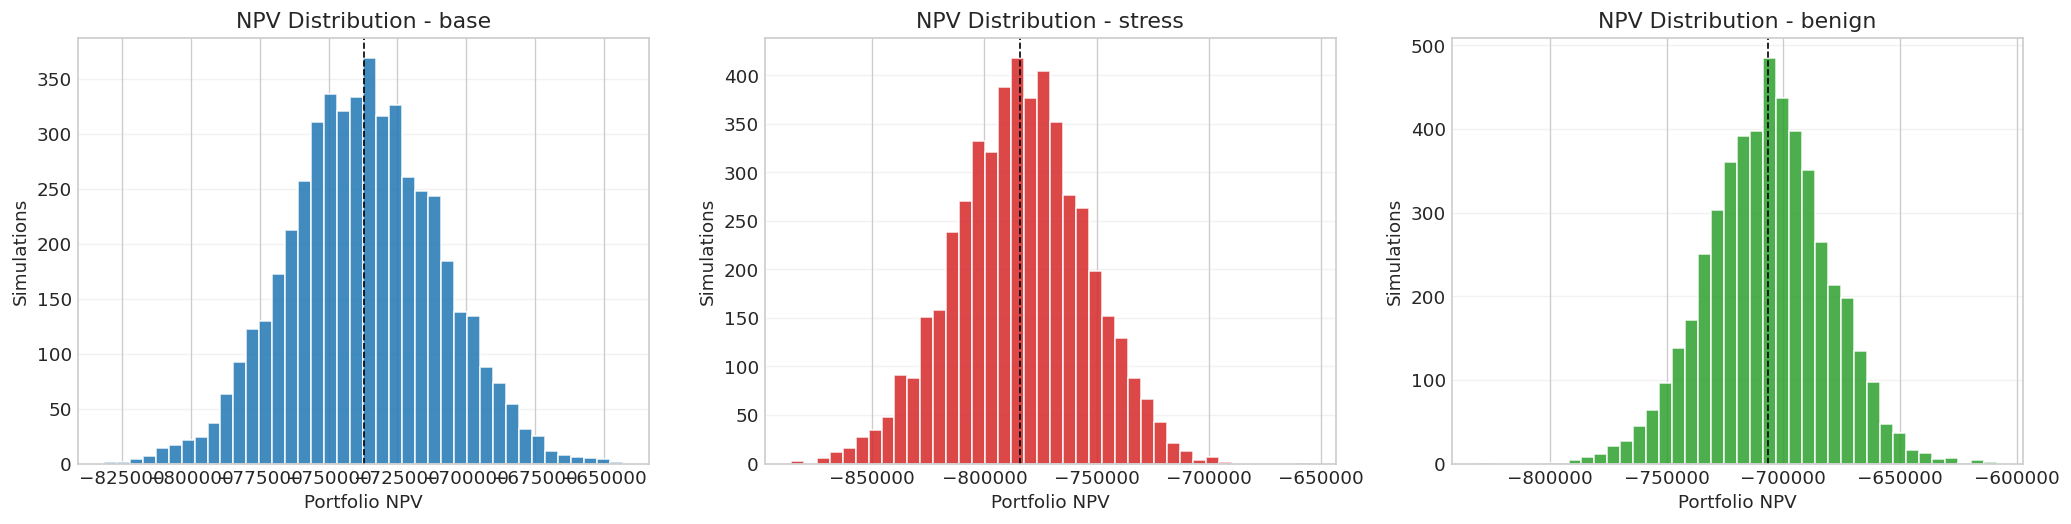

base     mean=-736,980.8  std=27,025.1  p05=-781,088.0  p95=-692,273.0
stress   mean=-784,036.6  std=29,169.7  p05=-833,561.9  p95=-736,442.4
benign   mean=-706,662.1  std=25,578.7  p05=-749,301.5  p95=-665,500.5


In [10]:
plot_npv_distributions(sims)

for sc in SCENARIOS:
    s = sims[sc]['npv']
    print(f'{sc:<8} mean={s.mean():,.1f}  std={s.std():,.1f}  p05={s.quantile(0.05):,.1f}  p95={s.quantile(0.95):,.1f}')

---
## 3. Comparison vs Deterministic Optimization

Compare simulated mean NPV with Notebook 04 `expected_npv`
for the integer strategy (`lp_round`).

In [11]:
det = df_opt[df_opt['strategy'] == 'lp_round'][['scenario', 'expected_npv']].copy()
cmp = sim_summary.merge(det, on='scenario', how='left')
cmp['delta_vs_expected'] = cmp['npv_mean'] - cmp['expected_npv']
cmp['delta_pct'] = cmp['delta_vs_expected'] / cmp['expected_npv'] * 100
display(cmp[['scenario', 'npv_mean', 'expected_npv', 'delta_vs_expected', 'delta_pct', 'var95', 'cvar95']].round(2))

,scenario,npv_mean,expected_npv,delta_vs_expected,delta_pct,var95,cvar95
0,base,-736980.80,322500.91,-1059481.71,-328.52,-781088.00,-792729.52
1,stress,-784036.56,285584.34,-1069620.90,-374.54,-833561.89,-845597.55
2,benign,-706662.08,341399.07,-1048061.15,-306.99,-749301.47,-761129.20


---
## 4. Sensitivity: p_accept and PD

Stress test NPV under parameter shocks:
- p_accept: 0.90x / 1.00x / 1.10x
- PD:       0.90x / 1.00x / 1.10x

,scenario,p_accept_mult,pd_mult,npv_mean,npv_p05,cvar95,avg_defaults
0,base,0.9,0.9,-560200.21,-601381.28,-612462.68,1621.53
1,base,0.9,1.0,-662628.71,-704445.64,-714410.65,1800.06
2,base,0.9,1.1,-766179.25,-810341.83,-823723.93,1980.54
3,base,1.0,0.9,-621984.99,-662718.93,-672932.09,1801.09
4,base,1.0,1.0,-737452.87,-779742.72,-791585.80,2001.86
5,base,1.0,1.1,-851405.99,-898703.01,-910742.61,2201.68
6,base,1.1,0.9,-684427.11,-729616.48,-742178.52,1981.46
7,base,1.1,1.0,-810686.17,-857148.07,-867568.89,2201.44
8,base,1.1,1.1,-937008.00,-984722.96,-997162.83,2422.12


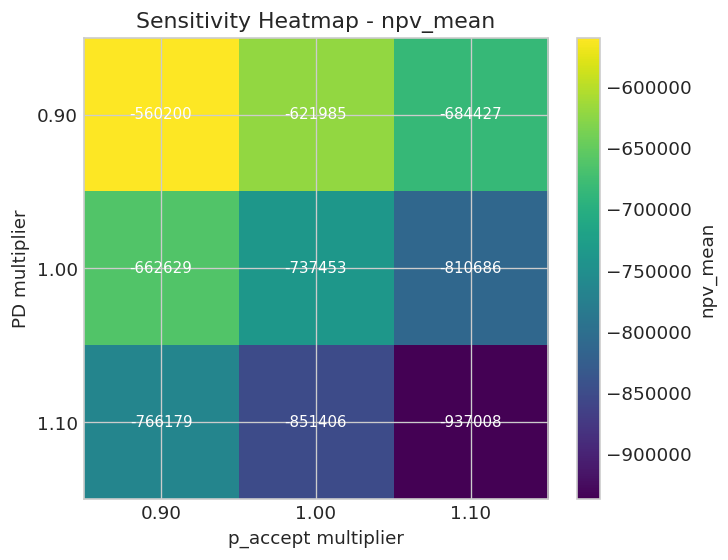

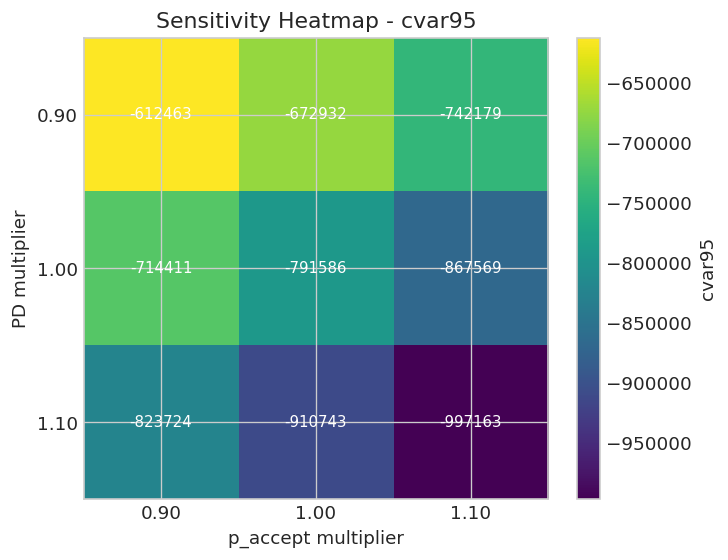

In [12]:
sens = run_sensitivity(
    df_demand,
    df_alloc,
    scenario='base',
    p_accept_multipliers=(0.90, 1.00, 1.10),
    pd_multipliers=(0.90, 1.00, 1.10),
    n_sims=3000,
    seed=123,
)
display(sens.round(2))

plot_sensitivity_heatmap(sens, value_col='npv_mean')
plot_sensitivity_heatmap(sens, value_col='cvar95')

---
## 5. Sanity checks

Validation invariants:
- `var95 <= npv_mean`,
- `cvar95 <= var95`,
- stress should not outperform benign in mean NPV.

In [15]:
assert (sim_summary['var95'] <= sim_summary['npv_mean']).all(), 'VaR95 above mean NPV'
assert (sim_summary['cvar95'] <= sim_summary['var95']).all(), 'CVaR95 above VaR95'

m = sim_summary.set_index('scenario')['npv_mean']
assert m['stress'] <= m['benign'], 'Stress unexpectedly better than Benign'

print('Sanity checks passed.')

Sanity checks passed.


---
## 6. Export

Save simulation aggregates and sensitivity table for final reporting.

In [14]:
out_sim = ROOT / 'data' / 'simulation_summary.csv'
out_sens = ROOT / 'data' / 'simulation_sensitivity.csv'
sim_summary.to_csv(out_sim, index=False)
sens.to_csv(out_sens, index=False)

print(f'Saved: {out_sim}')
print(f'Saved: {out_sens}')
print(f'simulation_summary shape: {sim_summary.shape}')
print(f'simulation_sensitivity shape: {sens.shape}')

Saved: /data/aturov/loan_limit_increases/data/simulation_summary.csv
Saved: /data/aturov/loan_limit_increases/data/simulation_sensitivity.csv
simulation_summary shape: (3, 11)
simulation_sensitivity shape: (9, 7)


---
## 7. Final Decision and Recommendation

### Executive summary

The recommended operational policy is to use a risk-adjusted decision rule `grant increase if incremental EV > 0` under the capital constraint, with `lp_round` as the deployable reference strategy because it matches the deterministic objective from Notebook 04 while remaining easy to operationalize.

### What the analysis shows

- In the base scenario, `lp_round` issues offers to 18,769 customers, or 62.6% of the portfolio.
- The strategy is tilted toward lower-risk segments: about 33.4% Prime, 55.2% Near-Prime, and only 11.4% Sub-Prime.
- Deterministic optimization produces `expected NPV = +322.5k`, but Monte Carlo simulation produces `mean NPV = -737.0k`, `VaR95 = -781.1k`, and `CVaR95 = -792.7k`.
- Therefore, under the current PD calibration, a broad rollout is not recommended.

### Model limitation

The Markov component is an approximation because the source dataset does not contain a full temporal panel of customer state migrations. Transition matrices should therefore be interpreted as scenario-based approximations rather than fully empirical roll-rate estimates.

### Business recommendation

1. Do not launch a broad rollout across the full eligible base under the current risk assumptions.
2. If a pilot is required, start with Prime and the upper part of Near-Prime, while excluding Sub-Prime from the first production wave.
3. Recalibrate PD and transition assumptions on real longitudinal payment/default history before deployment.
4. Use pilot monitoring with clear business KPIs: approval rate, realized default rate, contribution profit, and capital usage.


In [ ]:
final_det = df_opt[df_opt['strategy'] == 'lp_round'][[
    'scenario',
    'expected_npv',
    'offered_customers',
    'capital_usage_pct',
    'mix_prime',
    'mix_near',
    'mix_sub',
]].copy()

final_cmp = final_det.merge(
    sim_summary[['scenario', 'npv_mean', 'var95', 'cvar95', 'avg_accepted', 'avg_defaults']],
    on='scenario',
    how='left',
)

final_cmp['offer_share_pct'] = final_cmp['offered_customers'] / len(df_demand) * 100
final_cmp['accept_rate_pct'] = final_cmp['avg_accepted'] / final_cmp['offered_customers'] * 100
final_cmp['default_rate_on_accepted_pct'] = final_cmp['avg_defaults'] / final_cmp['avg_accepted'] * 100
final_cmp['mix_prime'] = final_cmp['mix_prime'] * 100
final_cmp['mix_near'] = final_cmp['mix_near'] * 100
final_cmp['mix_sub'] = final_cmp['mix_sub'] * 100

cols = [
    'scenario',
    'offer_share_pct',
    'expected_npv',
    'npv_mean',
    'var95',
    'cvar95',
    'accept_rate_pct',
    'default_rate_on_accepted_pct',
    'mix_prime',
    'mix_near',
    'mix_sub',
]

display(final_cmp[cols].round(2))

base_row = final_cmp[final_cmp['scenario'] == 'base'].iloc[0]
print('Recommended production policy: lp_round with EV > 0 gating and a tighter first-wave risk filter')
print(f"Base scenario offer share: {base_row['offer_share_pct']:.1f}% of customers")
print(f"Deterministic expected NPV: ${base_row['expected_npv']:,.0f}")
print(f"Monte Carlo mean NPV: ${base_row['npv_mean']:,.0f}")
print(f"Monte Carlo VaR95 / CVaR95: ${base_row['var95']:,.0f} / ${base_row['cvar95']:,.0f}")
print(f"Offer mix Prime / Near-Prime / Sub-Prime: {base_row['mix_prime']:.1f}% / {base_row['mix_near']:.1f}% / {base_row['mix_sub']:.1f}%")